In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
df = pd.read_csv("country_wise_latest.csv")

In [3]:
print("Head:\n", df.head())

Head:
   Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737 

In [4]:
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-nul

In [5]:
print("\nDescribe:\n", df.describe())


Describe:
           Confirmed         Deaths     Recovered        Active     New cases  \
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02    187.000000   
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04   1222.957219   
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05   5710.374790   
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02      4.000000   
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03     49.000000   
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03    419.500000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  56336.000000   

        New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
count   187.000000     187.000000          187.000000             187.000000   
mean     28.957219     933.812834            3.019519              64.820535   
std     120.037173    4197.

In [6]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [7]:
print("\nShape (rows, columns):", df.shape)


Shape (rows, columns): (187, 15)


In [8]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


In [9]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


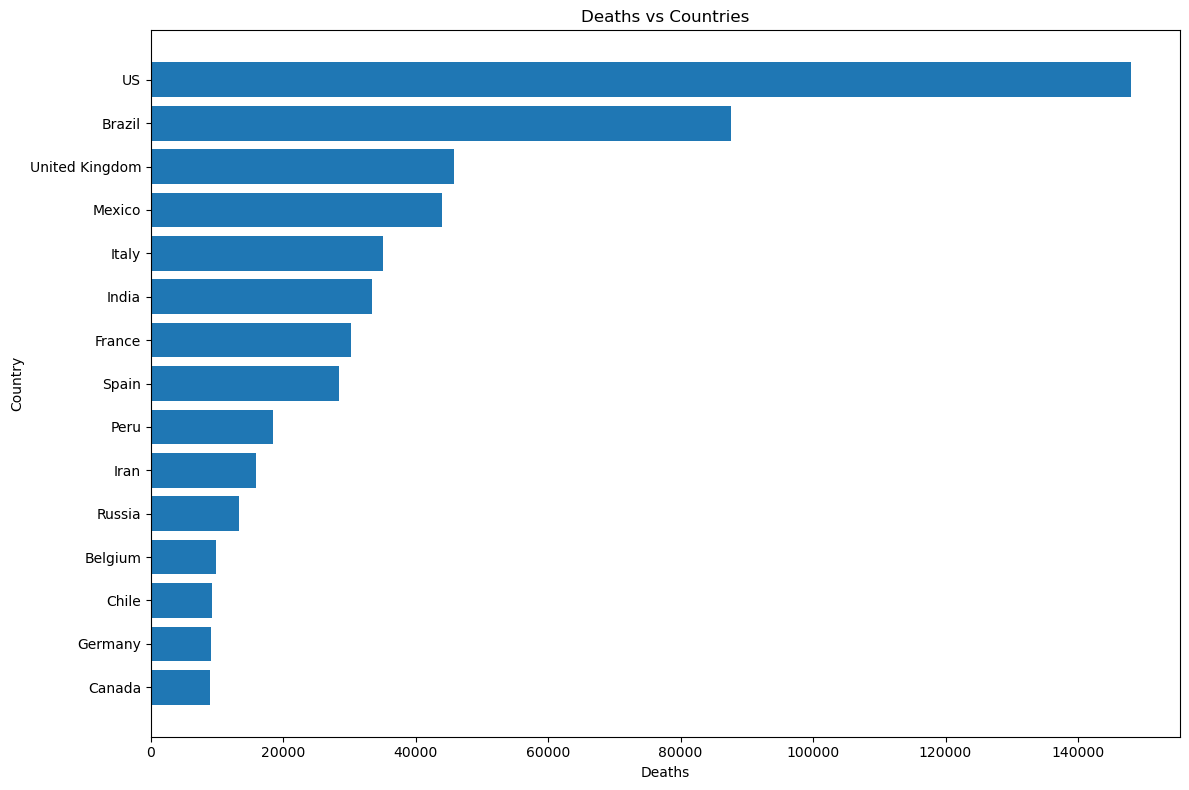

In [10]:
df_sorted = df.sort_values(by="Deaths", ascending=False).head(15)
plt.figure(figsize=(12,8))
plt.barh(df_sorted["Country/Region"], df_sorted["Deaths"])
plt.xlabel("Deaths")
plt.ylabel("Country")
plt.title("Deaths vs Countries")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

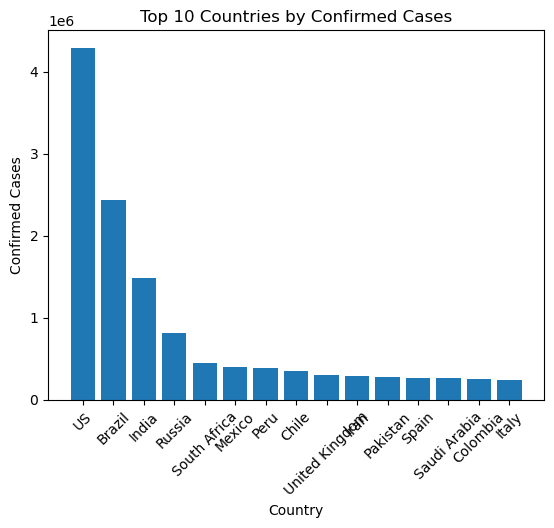

In [11]:
df_sorted = df.sort_values(by='Confirmed', ascending=False).head(15)
plt.figure()
plt.bar(df_sorted['Country/Region'], df_sorted['Confirmed'])
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Confirmed Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.show()

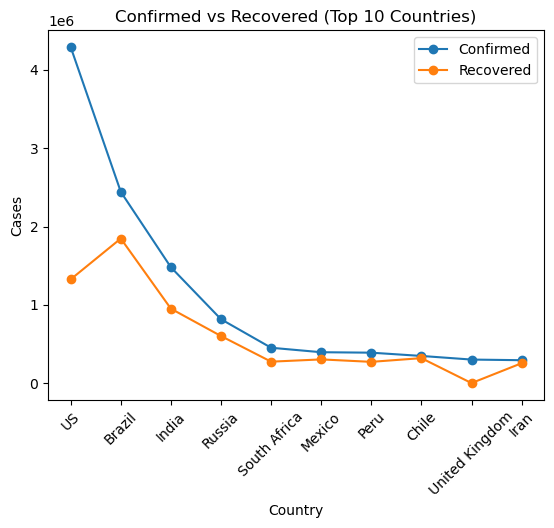

In [12]:
top10 = df.sort_values(by='Confirmed', ascending=False).head(10)
plt.figure()
plt.plot(top10['Country/Region'], top10['Confirmed'], marker='o')
plt.plot(top10['Country/Region'], top10['Recovered'], marker='o')
plt.xticks(rotation=45)
plt.title('Confirmed vs Recovered (Top 10 Countries)')
plt.xlabel('Country')
plt.ylabel('Cases')
plt.legend(['Confirmed', 'Recovered'])
plt.show()

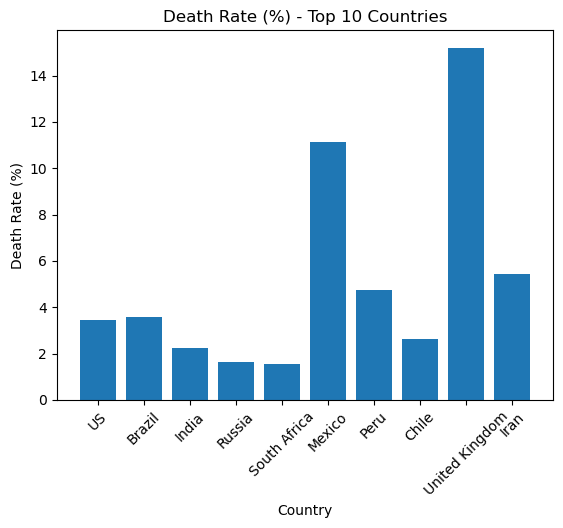

In [13]:
df['Death Rate (%)'] = (df['Deaths'] / df['Confirmed']) * 100
top10 = df.sort_values(by='Confirmed', ascending=False).head(10)
plt.figure()
plt.bar(top10['Country/Region'], top10['Death Rate (%)'])
plt.xticks(rotation=45)
plt.title('Death Rate (%) - Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Death Rate (%)')
plt.show()

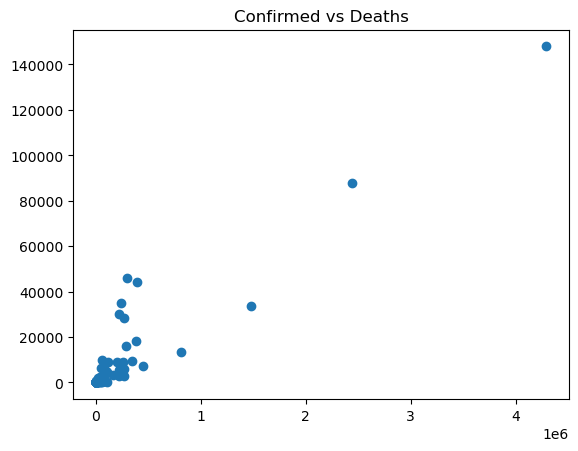

In [14]:
plt.scatter(df['Confirmed'], df['Deaths'])
plt.title('Confirmed vs Deaths')
plt.show()

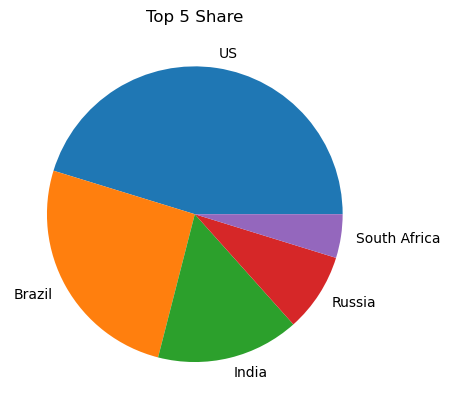

In [15]:
top5 = df.sort_values(by='Confirmed', ascending=False).head(5)
plt.pie(top5['Confirmed'], labels=top5['Country/Region'])
plt.title('Top 5 Share')
plt.show()

In [16]:

from dash import Dash, dcc, html, Input, Output
import plotly.express as px
app = Dash(__name__)
app.layout = html.Div([
    dcc.Dropdown(
        id='metric',
        options=[
            {'label': 'Confirmed', 'value': 'Confirmed'},
            {'label': 'Recovered', 'value': 'Recovered'},
            {'label': 'Deaths', 'value': 'Deaths'}
        ],
        value='Confirmed'
    ),
    dcc.Graph(id='bar-chart')
])
@app.callback(
    Output('bar-chart', 'figure'),
    Input('metric', 'value')
)
def update_chart(selected_metric):
    top_data = df.sort_values(
        by=selected_metric,
        ascending=False
    ).head(50)
    fig = px.bar(
        top_data,
        x='Country/Region',
        y=selected_metric,
        color=selected_metric,
        title=f"Top Countries by {selected_metric}",
        template='plotly_dark'
    )
    fig.update_layout(
        xaxis_tickangle=-90,
        height=600
    )
    return fig
app.run(jupyter_mode='inline')

In [17]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
app_high_contrast = Dash(__name__)
app_high_contrast.layout = html.Div([
    html.H2("Global COVID-19 Impact:  View", 
            style={'textAlign': 'center', 'color': '#00FFD1', 'letterSpacing': '2px'}),
    html.Div([
        dcc.Dropdown(
            id='hc-metric',
            options=[
                {'label': 'Confirmed', 'value': 'Confirmed'},
                {'label': 'Recovered', 'value': 'Recovered'},
                {'label': 'Deaths', 'value': 'Deaths'}
            ],
            value='Confirmed',
            style={'width': '280px', 'margin': '0 auto', 'borderRadius': '10px'}
        ),
    ], style={'padding': '15px'}),
    dcc.Graph(id='hc-sunburst')
], style={'backgroundColor': '#050505', 'padding': '40px', 'borderRadius': '20px', 'border': '1px solid #333'})
@app_high_contrast.callback(
    Output('hc-sunburst', 'figure'),
    Input('hc-metric', 'value')
)
def update_hc_visual(selected_metric):
    # Top 50 for high density
    sun_data = df.sort_values(by=selected_metric, ascending=False).head(50)
    fig = px.sunburst(
        sun_data,
        path=[px.Constant("GLOBAL"), 'Country/Region'],
        values=selected_metric,
        color=selected_metric,
        # 'Electric' or 'IceFire' provide extreme contrast on black
        color_continuous_scale='Electric', 
        template='plotly_dark'
    )
    fig.update_traces(
        marker=dict(line=dict(color='#050505', width=2)), # Adds a black gap between slices
        insidetextorientation='radial' # Makes text easier to read in thin slices
    )
    fig.update_layout(
        margin=dict(t=20, l=20, r=20, b=20),
        height=700,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        coloraxis_colorbar=dict(title="Scale", tickprefix=" ")
    )
    return fig
if __name__ == '__main__':
    # Running on port 8052 to avoid conflict with your previous cells
    app_high_contrast.run(jupyter_mode='inline', port=8052, debug=True)